# Multiple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Startups_data.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df.shape

(50, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [5]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [6]:
df.duplicated().sum()   #No duplicates

0

In [7]:
# Dropping unnecessary columns - State
df.drop(columns='State',inplace=True)

In [8]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit
0,165349.20,136897.80,471784.10,192261.83
1,162597.70,151377.59,443898.53,191792.06
2,153441.51,101145.55,407934.54,191050.39
3,144372.41,118671.85,383199.62,182901.99
4,142107.34,91391.77,366168.42,166187.94


In [9]:
df.isnull().sum()   # No missing values

R&D Spend          0
Administration     0
Marketing Spend    0
Profit             0
dtype: int64

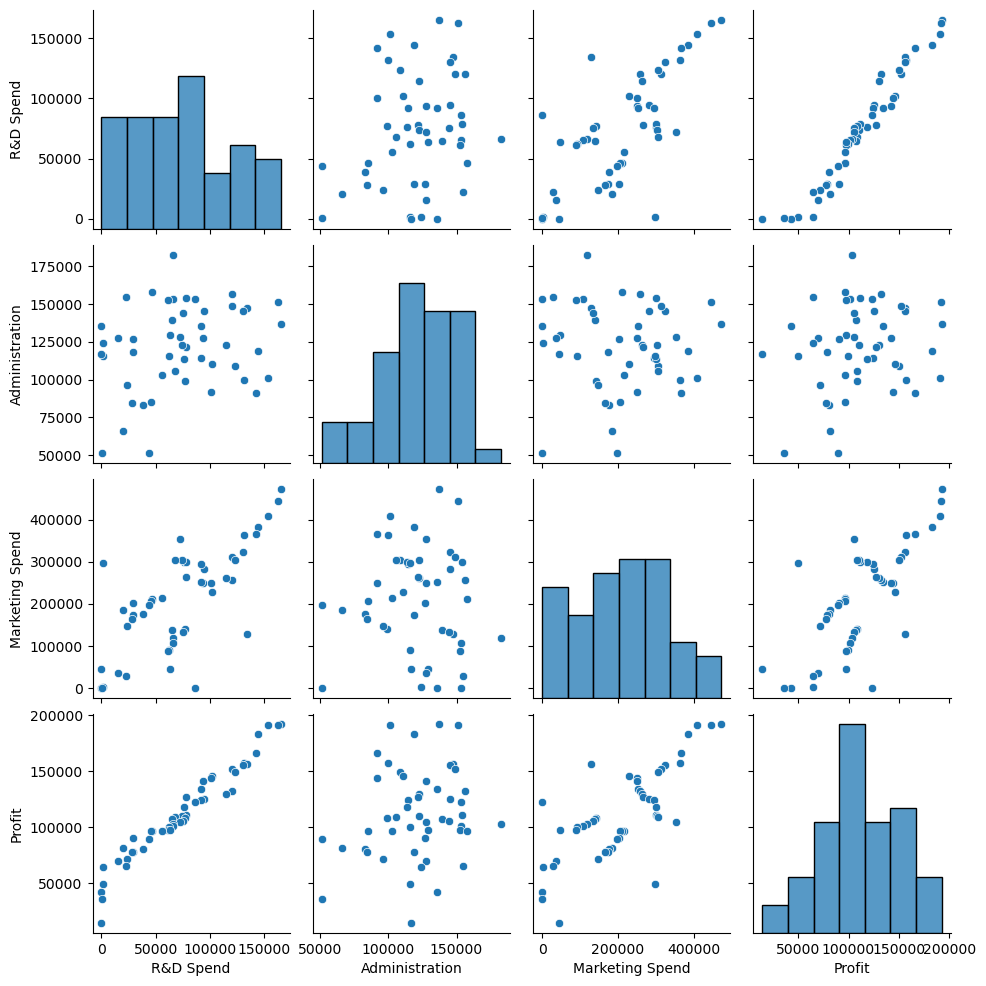

In [10]:
# Visualizing data
sns.pairplot(df)
plt.show()

In [11]:
# Correlation matrix of the dataset
df.corr()

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


In [12]:
# independent features
X = df[['R&D Spend','Administration','Marketing Spend']]    # or accessed using df.iloc[:,:,-1]
X.head(3)

,R&D Spend,Administration,Marketing Spend
0,165349.20,136897.80,471784.10
1,162597.70,151377.59,443898.53
2,153441.51,101145.55,407934.54


In [13]:
# dependent feature
y = df['Profit']
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

In [14]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

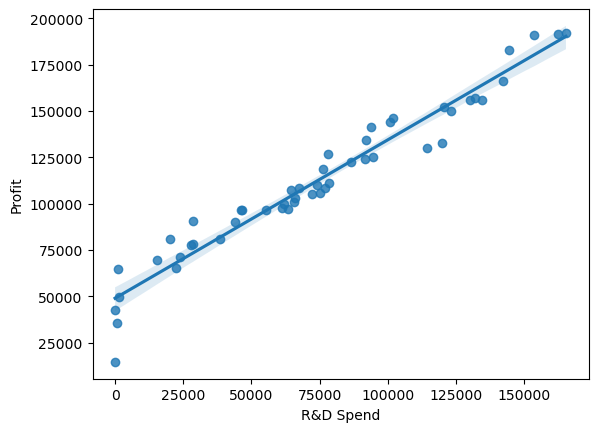

In [15]:
sns.regplot(x='R&D Spend', y= 'Profit',data=df)
plt.show()

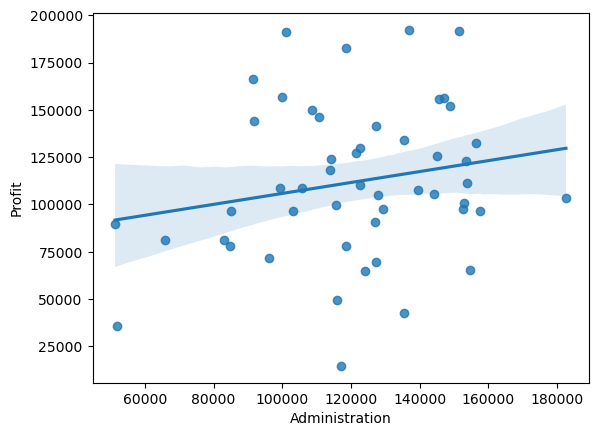

In [16]:
sns.regplot(x='Administration', y= 'Profit',data=df)
plt.show()

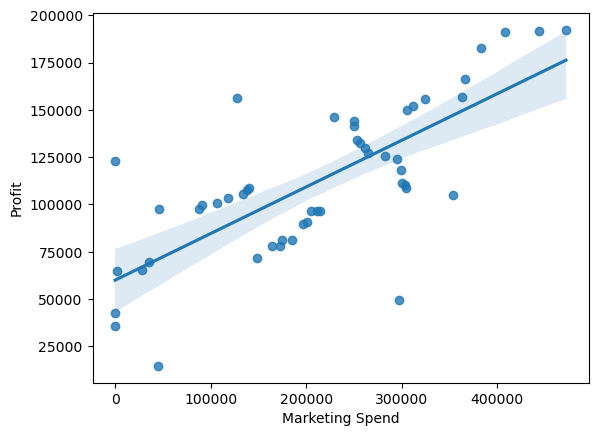

In [17]:
sns.regplot(x='Marketing Spend', y= 'Profit',data=df)
plt.show()

In [18]:
# Standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [19]:
X_train = scaler.fit_transform(X_train)

In [20]:
X_train

array([[ 1.30948713,  0.94663711, -0.85542942],
       [-0.96661844, -1.50749007, -0.53664892],
       [-1.53344439, -0.28587018,  0.61382091],
       [-1.56149962,  0.48431128, -1.96316611],
       [ 0.88098185, -0.01878555,  0.30731897],
       [ 1.06890261, -0.56616681,  0.68205579],
       [ 0.1023108 , -0.05881665,  0.32960808],
       [ 0.0816425 , -0.9352526 , -0.74390717],
       [-0.57135605,  1.35881459, -0.13483753],
       [-0.25762459,  1.16276121, -1.19801576],
       [ 1.96495539,  0.54207791,  2.12879731],
       [-1.0885079 ,  1.24540132, -1.71740828],
       [-0.02363789,  0.18731045,  1.10013177],
       [-0.37796249, -0.78694993, -0.10155655],
       [ 1.25108099, -0.91430529,  1.18406885],
       [-0.16231067,  1.17572697, -1.03391408],
       [ 0.58556331, -1.22943988,  0.20296362],
       [-0.95017849,  0.1555641 , -0.2187165 ],
       [ 1.90627327,  1.11075012,  1.88693513],
       [ 0.11033755,  1.20484317,  0.63656972],
       [ 1.71099629, -0.86203853,  1.575

In [21]:
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [23]:
regression.fit(X_train,y_train)

LinearRegression()

In [24]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring="neg_mean_squared_error",cv=5)        
# cv=5 means each 1/5 of training data will act as test data for 3 iterations and each time will return negative value of mean squared error.
# will consider the average of all the negative mean squared errors (validation_scores)

In [25]:
np.mean(validation_score)

-96954745.25174412

In [26]:
## prediction
y_pred = regression.predict(X_test)

In [27]:
y_pred

array([125972.1482631 ,  85471.92270964,  98924.15168288,  46639.7862872 ,
       128142.12473185,  52602.19053671, 108364.69760175, 100331.58846892,
        97538.56674666, 112496.70398401, 128110.85388838, 173383.29618108,
        93334.03668271, 149432.23776236, 173293.94964905])

In [28]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
mse = mean_squared_error(y_test,y_pred)
print("MSE: ",mse)
mae = mean_absolute_error(y_test,y_pred)
print("MAE: ",mae)
rmse = root_mean_squared_error(y_test,y_pred)
print("RMSE: ",rmse)
rsquared = r2_score(y_test,y_pred)
print("R2 score: ",rsquared) 
adj_rsquared = 1 - (1-rsquared)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2 score: ",adj_rsquared) 

MSE:  81772149.43547153
MAE:  7222.594346965519
RMSE:  9042.795443637522
R2 score:  0.9418819530700164
Adjusted R2 score:  0.9260315766345664


### Observations:-

The model is performing great with 0.94 r2 score

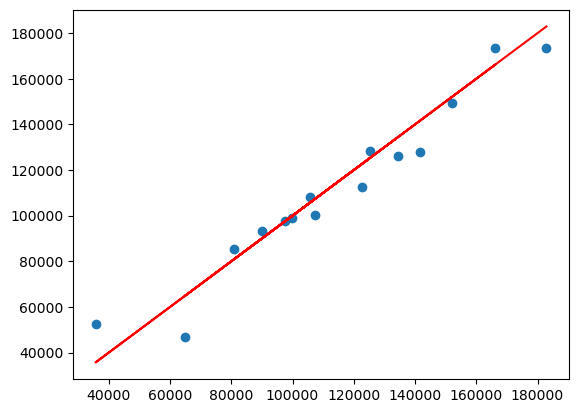

In [40]:
# Visualize accuracy
plt.scatter(y_test,y_pred)
plt.plot(y_test,y_test,color='red')
plt.show()

In [30]:
residuals = y_test - y_pred
residuals

13     8335.201737
39    -4466.162710
30     1013.438317
45    18286.293713
17    -2771.754732
48   -16928.780537
26    -2631.157602
25     7072.751531
32     -110.726747
19    10280.156016
12    13474.666112
4     -7195.356181
37    -3384.896683
8      2779.532238
3      9608.040351
Name: Profit, dtype: float64

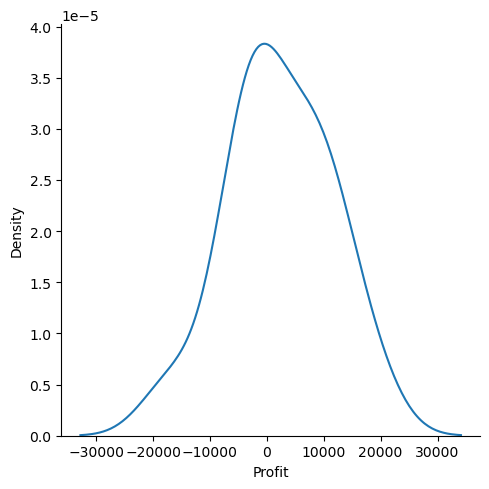

In [31]:
# Plot these residuals
sns.displot(residuals,kind='kde')
plt.show()

If the curve is somewhat of a normal distribution, then the model is good

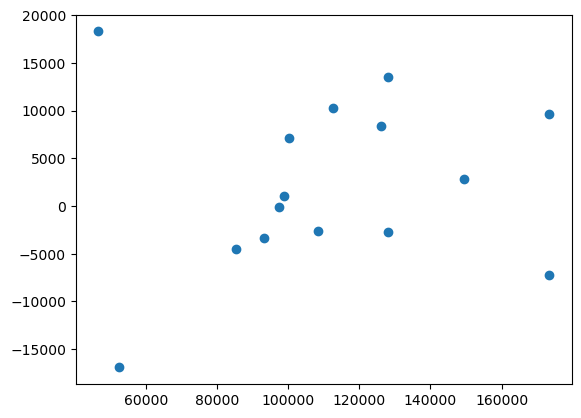

In [32]:
## scatter plot with respect to predictions and residuals
plt.scatter(y_pred,residuals)
plt.show()                          # It has a uniform distribution, then there is no problem.

In [33]:
pd.DataFrame({'Actual':y_test,'Predicted':y_pred, 'Difference':residuals}).head(10)

,Actual,Predicted,Difference
13,134307.35,125972.148263,8335.201737
39,81005.76,85471.922710,-4466.162710
30,99937.59,98924.151683,1013.438317
45,64926.08,46639.786287,18286.293713
17,125370.37,128142.124732,-2771.754732
48,35673.41,52602.190537,-16928.780537
26,105733.54,108364.697602,-2631.157602
25,107404.34,100331.588469,7072.751531
32,97427.84,97538.566747,-110.726747
19,122776.86,112496.703984,10280.156016


In [34]:
## OLS Regression
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
prediction = model.predict(X_test)
prediction

array([ 14736.93512024, -25763.29043322, -12311.06145997, -64595.42685565,
        16906.91158899, -58633.02260615,  -2870.51554111, -10903.62467394,
       -13696.6463962 ,   1261.49084115,  16875.64074553,  62148.08303822,
       -17901.17646015,  38197.0246195 ,  62058.7365062 ])

In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Profit   R-squared (uncentered):                   0.113
Model:                            OLS   Adj. R-squared (uncentered):              0.030
Method:                 Least Squares   F-statistic:                              1.359
Date:                Sat, 03 May 2025   Prob (F-statistic):                       0.273
Time:                        15:45:26   Log-Likelihood:                         -456.46
No. Observations:                  35   AIC:                                      918.9
Df Residuals:                      32   BIC:                                      923.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           3.76e+04   3.03e+04      1.239      0.224   -2.42e+04    9.94e+04
x2         -2245.5008   2.13e+04     -0.105      0.917   -4.56e+04    4.12e+04
x3          3384.6629   3.02e+04      0.112      0.911    -5.8e+04    6.48e+04
==============================================================================
Omnibus:                       16.944   Durbin-Watson:                   0.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.711
Skew:                          -1.275   Prob(JB):                     7.10e-06
Kurtosis:                       6.124   Cond. No.                         2.73
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
regression.coef_

array([37601.99805033, -2245.50077459,  3384.66290938])

We can see from both methods, coefficients are almost same.

In [37]:
## Predicting new data
regression.predict(scaler.transform([[93863.75,127320.38,249839.44]]))

array([128110.85388838])